In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data = pd.read_csv("data/retail_price.csv")


In [19]:
# Check duplicates
duplicates = data.duplicated().sum()
print("Duplicate rows:", duplicates)

# Remove duplicates if any
data = data.drop_duplicates()

Duplicate rows: 0


Outlier Detection & Handling

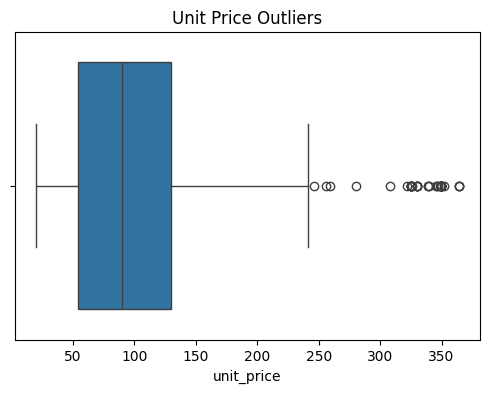

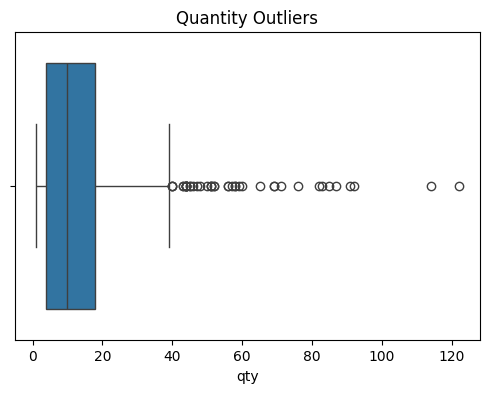

In [20]:
plt.figure(figsize=(6,4))
sns.boxplot(x=data['unit_price'])
plt.title("Unit Price Outliers")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=data['qty'])
plt.title("Quantity Outliers")
plt.show()

In [21]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    return df[(df[column] >= lower) & (df[column] <= upper)]

# Apply for key columns
data = remove_outliers(data, 'unit_price')
data = remove_outliers(data, 'qty')

print("Shape after outlier removal:", data.shape)

Shape after outlier removal: (592, 30)


In [22]:
# Convert date column
data['month_year'] = pd.to_datetime(data['month_year'])

# Check
data.dtypes

product_id                            object
product_category_name                 object
month_year                    datetime64[ns]
qty                                    int64
total_price                          float64
freight_price                        float64
unit_price                           float64
product_name_lenght                    int64
product_description_lenght             int64
product_photos_qty                     int64
product_weight_g                       int64
product_score                        float64
customers                              int64
weekday                                int64
weekend                                int64
holiday                                int64
month                                  int64
year                                   int64
s                                    float64
volume                                 int64
comp_1                               float64
ps1                                  float64
fp1       

In [23]:
# Extract useful features
data['month'] = data['month_year'].dt.month
data['year'] = data['month_year'].dt.year

# Optional: day info if needed
data['day_of_week'] = data['month_year'].dt.dayofweek

In [24]:
# Apply log transformation
data['log_qty'] = np.log1p(data['qty'])
data['log_price'] = np.log1p(data['unit_price'])

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

data[['unit_price', 'qty']] = scaler.fit_transform(data[['unit_price', 'qty']])

In [26]:
# One-hot encoding
data = pd.get_dummies(data, columns=['product_category_name'], drop_first=True)

In [27]:
# Drop unnecessary columns
data = data.drop(['product_id', 'month_year'], axis=1)

In [28]:
data.head()
data.shape
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 592 entries, 0 to 675
Data columns (total 38 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   qty                                          592 non-null    float64
 1   total_price                                  592 non-null    float64
 2   freight_price                                592 non-null    float64
 3   unit_price                                   592 non-null    float64
 4   product_name_lenght                          592 non-null    int64  
 5   product_description_lenght                   592 non-null    int64  
 6   product_photos_qty                           592 non-null    int64  
 7   product_weight_g                             592 non-null    int64  
 8   product_score                                592 non-null    float64
 9   customers                                    592 non-null    int64  
 10  weekday

In [29]:
data.to_csv("data/cleaned_data.csv", index=False)